# Week 7 — Визуализация данных (matplotlib + data storytelling)

В этом ноутбуке:

- Анализ витрины `mart_daily` из проекта.
- 3 графика: временной ряд, распределение и ранжирование.
- Краткие выводы по каждому графику.

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use("seaborn-v0_8")

pd.set_option("display.max_rows", 10)
pd.set_option("display.width", 120)

notebook_dir = Path.cwd()
print("Текущая папка ноутбука:", notebook_dir)

Текущая папка ноутбука: C:\Users\Artem\Desktop\end-to-end-project\notebooks


## Витрина mart_daily

Работаем с дневной витриной:

- Зерно: одна строка = один день по одному городу.
- Примеры KPI: `temp_mean_c`, `temp_max_c`, `temp_min_c`, `humidity_mean_pct`,
  `precip_sum_mm`, `wind_max_kmh`, `rainy_hours_count`, `temp_7d_avg`, `precip_7d_sum`.

In [17]:
fmart_dir = Path("..") / "data" / "mart" / "variant_05"
files = sorted(mart_dir.glob("mart_daily_*.csv"))

print("Ищем файлы в:", mart_dir.resolve())
for f in files:
    print(" -", f.name)

if not files:
    raise FileNotFoundError("Не найдено ни одного файла mart_daily_*.csv в ../data/mart/variant_05")

latest_file = files[-1]
print("Используем файл mart:", latest_file)

df = pd.read_csv(latest_file)
df["date"] = pd.to_datetime(df["date"])

print(df.head())
print()
print("Типы колонок:")
print(df.dtypes)
print()
print("Диапазон дат:", df["date"].min(), "→", df["date"].max())
print("Строк всего:", len(df))

Ищем файлы в: C:\Users\Artem\Desktop\end-to-end-project\data\mart\variant_05
 - mart_daily_2026-05-16_23-25-57.csv
 - mart_daily_2026-05-20_19-20-50.csv
 - mart_daily_2026-05-20_19-21-05.csv
 - mart_daily_2026-05-20_19-33-30.csv
 - mart_daily_2026-05-20_19-33-57.csv
 - mart_daily_2026-05-26_20-00-27.csv
Используем файл mart: ..\data\mart\variant_05\mart_daily_2026-05-26_20-00-27.csv
        date city_id city_name  temp_mean_c  temp_max_c  temp_min_c  humidity_mean_pct  precip_sum_mm  wind_max_kmh  \
0 2026-05-26  US_NYC  Нью-Йорк    21.087500        27.1        14.6          61.375000            0.0          12.2   
1 2026-05-27  US_NYC  Нью-Йорк    24.166667        31.3        17.7          63.916667            0.0          20.6   
2 2026-05-28  US_NYC  Нью-Йорк    20.550000        24.1        16.7          52.041667            0.0          22.0   
3 2026-05-29  US_NYC  Нью-Йорк    19.262500        23.9        14.5          50.375000            0.0          28.0   
4 2026-05-30  US_NY

## График 1 — временной ряд (time series)

**Вопрос:** Как меняется средняя дневная температура со временем?

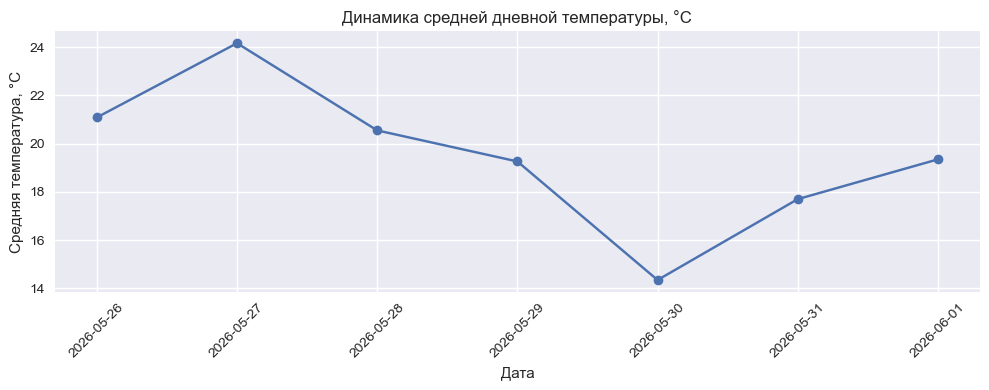

In [18]:
df_ts = df.sort_values("date")

fig_ts = plt.figure(figsize=(10, 4))
plt.plot(df_ts["date"], df_ts["temp_mean_c"], marker="o")
plt.title("Динамика средней дневной температуры, °C")
plt.xlabel("Дата")
plt.ylabel("Средняя температура, °C")
plt.xticks(rotation=45)
plt.tight_layout()

fig_ts.savefig(notebook_dir / "week7_timeseries.png", dpi=150)
plt.show()

**Вывод по графику 1**

На отрезке видно краткосрочный подъём температуры с последующим снижением и частичным восстановлением. Пик средней дневной температуры приходится на 27 мая, минимум — 30 мая, затем 31 мая – 1 июня температура снова немного растёт.

## График 2 — распределение средней температуры

**Вопрос:** В каких пределах обычно лежит средняя дневная температура и есть ли выбросы?

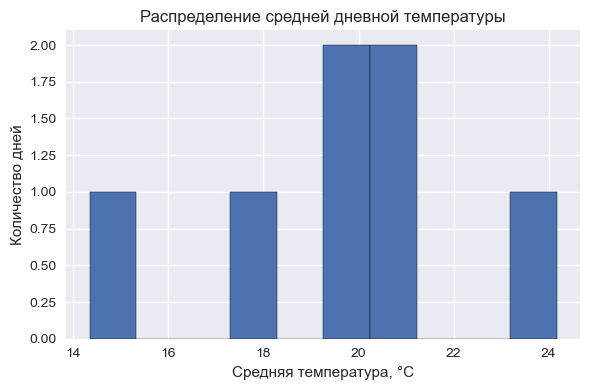

In [19]:
fig_dist = plt.figure(figsize=(6, 4))
plt.hist(df["temp_mean_c"].dropna(), bins=10, edgecolor="black")
plt.title("Распределение средней дневной температуры")
plt.xlabel("Средняя температура, °C")
plt.ylabel("Количество дней")
plt.tight_layout()

fig_dist.savefig(notebook_dir / "week7_distribution.png", dpi=150)
plt.show()

**Вывод по графику 2**

Большинство дней имеют среднюю температуру в диапазоне от 18 до 21 °C, значения сгруппированы вокруг умеренных температур. Отдельно выделяются более прохладный день 15 °C и более тёплый день 24 °C, их можно считать крайними значениями. В целом диапазон температур относительно узкий, поэтому разброс средней дневной температуры по дням невелик.

## График 3 — ранжирование по осадкам

**Вопрос:** В какие дни было больше всего осадков?

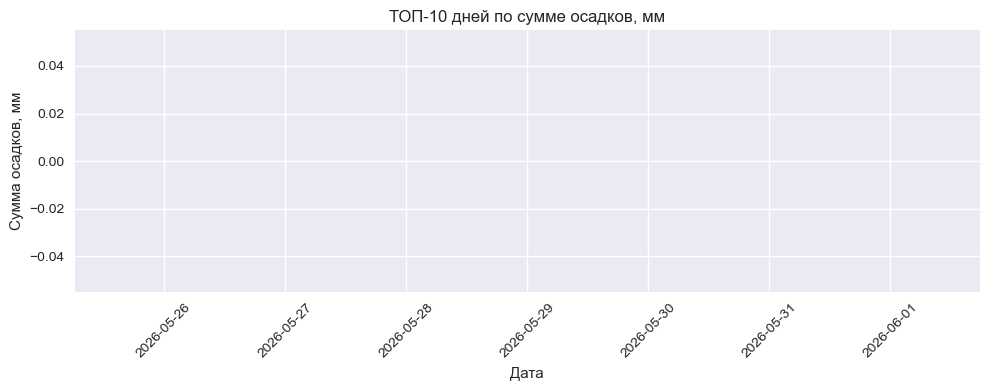

,date,precip_sum_mm
0,2026-05-26,0.0
1,2026-05-27,0.0
2,2026-05-28,0.0
3,2026-05-29,0.0
4,2026-05-30,0.0
5,2026-05-31,0.0
6,2026-06-01,0.0


In [20]:
df_rain = df.sort_values("precip_sum_mm", ascending=False).head(10)

fig_rank = plt.figure(figsize=(10, 4))
plt.bar(df_rain["date"].dt.strftime("%Y-%m-%d"), df_rain["precip_sum_mm"])
plt.title("ТОП-10 дней по сумме осадков, мм")
plt.xlabel("Дата")
plt.ylabel("Сумма осадков, мм")
plt.xticks(rotation=45)
plt.tight_layout()

fig_rank.savefig(notebook_dir / "week7_ranking.png", dpi=150)
plt.show()

df_rain[["date", "precip_sum_mm"]]

**Вывод по графику 3**

Во всех рассматриваемых днях сумма осадков по данным витрины равна 0 мм.

## Итог

- Построены 3 графика под разные аналитические вопросы: временной ряд, распределение и ранжирование.
- Даты приведены к типу datetime и отсортированы по времени.
- По каждому графику сформулированы конкретные выводы, которые помогают интерпретировать данные, а не просто показывают картинку.